# Parameter Optimise on start-up

Here we force that the source $\hat{Q}$ to satisfy $\mathcal{L}\hat{Q}=0$

In [1]:
include("param_code.jl")

optimise_param (generic function with 2 methods)

### Analytically informed optimisation

In [2]:
n = 150
len = sqrt(pi)*pi/2
A = optimise_param(len, 5*len, n)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:   337642
Number of nonzeros in inequality constraint Jacobian.:     2048
Number of nonzeros in Lagrangian Hessian.............:    41088

Total number of variables............................:    91213
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        1
Total number of equality constraints.................:    91204
Total number of inequality c

([0.0 0.0 … 0.0 0.0; 0.0 6.961768727055206e-20 … 5.0267190845595734e-20 0.0; … ; 0.0 5.528165731117147e-20 … 4.7244148706256526e-20 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 -4.0132991108402265e-20 … -8.863331258362202e-20 0.0; … ; 0.0 -5.241197395929026e-20 … -4.7839160522619005e-20 0.0; 0.0 0.0 … 0.0 0.0], [-0.09359176612468466 -0.0846228806057951 … -0.02185387881008449 -0.023397716380116066; -0.0853179454998945 -0.07596850037040281 … -0.019671252738212065 -0.0213097595055317; … ; -0.10757365156939051 -0.09958620018122939 … -0.025560641175711434 -0.026895408205799425; -0.11455546127313866 -0.10704240848247895 … -0.027617723067663493 -0.02883218753236695], [0.12857261737595194 0.13397764135429435 … 0.02872058186472994 0.02689674479885606; 0.13488219195284257 0.13970860600463872 … 0.029716141621615233 0.028015176212100194; … ; 0.11465300328732318 0.12089745268446551 … 0.02668763860901895 0.02469802289618125; 0.10684606327938469 0.11358016869005536 … 0.02521117265308099 0.0231151

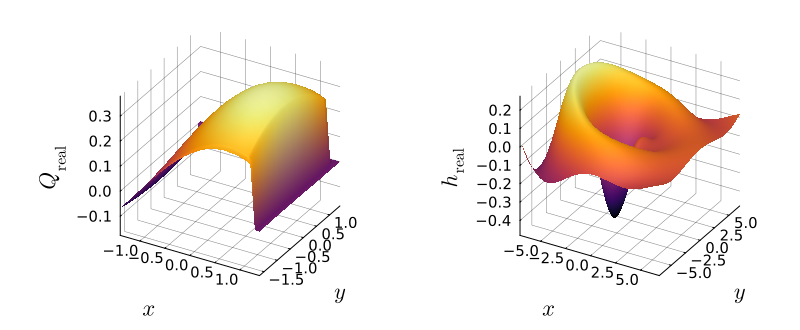

In [ ]:
theme(:default)
space_array = -5*len/2-A[5]:A[5]:5*len/2
l_i = len
p= Plots.plot(Plots.surface(space_array, space_array, A[1],zlabel=L"Q_{\textrm{real}}",
        xlims=[-l_i/2,l_i/2],ylims=[-len/2-3*A[5],len/2]), 
    Plots.surface(space_array, space_array, A[3],zlabel=L"h_{\textrm{real}}"),colorbar=false,xlabel=L"x",ylabel=L"y",
    labelfontsize=15,tickfontsize=10,gridalpha=0.5,size=(800,330))

In [4]:
pwr = sup_q_pwr(A[6], A[7], A[6], A[7], A[5], A[5], A[1], A[2], A[3], A[4],0)
print("Thrust = ", A[9],
        "\nPower = ", pwr)
print("\nEfficiency = ", A[9]/pwr,"\n")
csts = A[8];
print("\nA_r = ",csts[1], 
        "\nA_i = ",csts[2],
        "\nB_r = ",csts[3],
        "\nB_i = ",csts[4],
        "\nC_r = ",csts[5],
        "\nC_i = ",csts[6],
        "\nD_r = ",csts[7],
        "\nD_i = ",csts[8],
        "\nk = ",csts[9])

Thrust = 0.24593029454361345
Power = 0.37068323778058593
Efficiency = 0.6634513500423885

A_r = -0.0121787700946526
A_i = -0.017077497865989815
B_r = 0.1452866363519262
B_i = 0.11993752954607438
C_r = -0.014122240447789675
C_i = -0.016882604875003846
D_r = 0.15079568295257917
D_i = 0.113148873254674
k = 0.8585579610661418

### Compare to numerical optimisation

In [ ]:
include(relpath("subcritical_square/subcrit_solver.jl","shape_in_wdp"))


angle_check (generic function with 1 method)

In [4]:
B = vel_opti(0,len,5*len,n)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:   317166
Number of nonzeros in inequality constraint Jacobian.:     2312
Number of nonzeros in Lagrangian Hessian.............:     6536

Total number of variables............................:    91204
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:    89156
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -3.3881318e-21 1.10e-01 1.36e-03  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

([0.0 0.0 … 0.0 0.0; 0.0 5.404501936647567e-20 … 1.4701681472398575e-19 0.0; … ; 0.0 1.2229887204855911e-20 … -4.2775423190110933e-20 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 -3.5037662683625894e-20 … -1.5226739436313296e-19 0.0; … ; 0.0 -6.001389586915001e-20 … -1.2063645653588123e-20 0.0; 0.0 0.0 … 0.0 0.0], [0.05249972423595684 0.04241724182065616 … 0.01230521347873023 0.014317966943465783; 0.04282111184574909 0.03254014481554366 … 0.00993566571851594 0.012003723046943006; … ; 0.06975742459198772 0.06035815799773025 … 0.016505688253659764 0.01835775152239464; 0.07862583469932494 0.06954045856085721 … 0.018910366094471772 0.020679206691598714], [-0.14912859489358948 -0.15173955747242285 … -0.03383655286890214 -0.0325512195908661; -0.1527613455225735 -0.15471299463520452 … -0.03413953861933085 -0.03300072767165421; … ; -0.1399103860137701 -0.14359755172945946 … -0.03298949968456222 -0.03147462889538588; -0.13447594576950386 -0.13876700813186063 … -0.03219935505453099 -0.030547

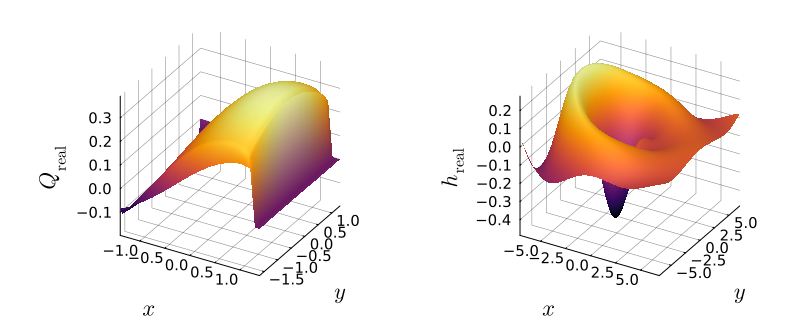

In [7]:
space_array = -5*len/2-B[5]:B[5]:5*len/2
l_i = len
p= Plots.plot(Plots.surface(space_array, space_array, B[1],zlabel=L"Q_{\textrm{real}}",
        xlims=[-l_i/2,l_i/2],ylims=[-len/2-3*B[5],len/2-B[5]]), 
    Plots.surface(space_array, space_array, B[3],zlabel=L"h_{\textrm{real}}"),colorbar=false,xlabel=L"x",ylabel=L"y",
    labelfontsize=15,tickfontsize=10,gridalpha=0.5,size=(800,330))

In [8]:
print("Thrust = ",B[8])
pwr1 = sup_q_pwr(B[6], B[7], B[6], B[7], B[5], B[5], B[1], B[2], B[3], B[4],0)
print("\nPower = ", pwr1)
print("\nEfficiency = ", B[8]/pwr1)

Thrust = 0.2489234194009293
Power = 0.37284968472574437
Efficiency = 0.6676240576253376

### Compare thrust and power values using absolute difference 

In [9]:
thrust_rel = (B[8]-A[9])/B[8]
pow_rel = (pwr1-pwr)/pwr1
print("Thrust relative difference = ", thrust_rel*100, "%\n",
    "Power relative difference = ", pow_rel*100,"%\n")

Thrust relative difference = 1.2024279854901707%
Power relative difference = 0.5810510331400723%


### Find the absolute difference



In [10]:
dif_real = zeros(n,n)
dif_imag = zeros(n,n)
for i in 1:n
    for j in 1:n
        dif_real[i,j] = abs(B[1][i,j]-A[1][i,j])
        dif_imag[i,j] = abs(B[2][i,j]-A[2][i,j])
    end
end


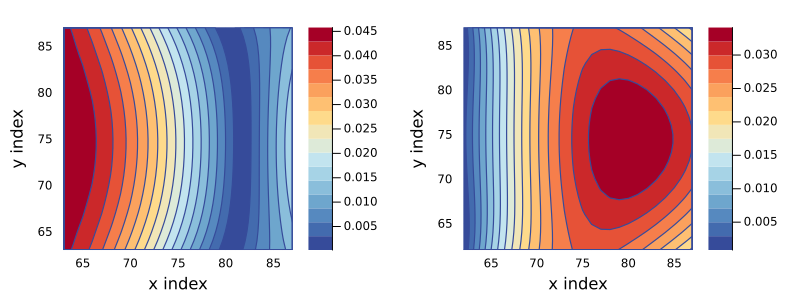

In [11]:
theme(:vibrant)
plot(contourf(63:87,63:87,dif_real[63:87,63:87]),
    contourf(62:87,62:87,dif_imag[62:87,62:87]),
    xlabel="x index", ylabel="y index", size=(800,300),
    margin=0.5Plots.cm)

In [12]:
h_dif_real = zeros(n,n)
h_dif_imag = zeros(n,n)
for i in 1:n
    for j in 1:n
        h_dif_real[i,j] = abs(B[3][i,j]-A[3][i,j])
        h_dif_imag[i,j] = abs(B[4][i,j]-A[4][i,j])
    end
end


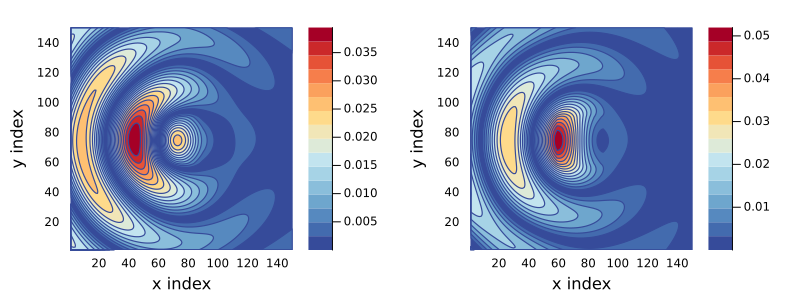

In [13]:
theme(:vibrant)
plot(contourf(h_dif_real),
    contourf(h_dif_imag),
    xlabel="x index", ylabel="y index", size=(800,300),
    margin=0.5Plots.cm)

---
### Comparing the satisfaction of $\mathcal{L}\hat{Q}=0$ in analytically informed case

In [7]:
dx = A[5]
l = A[6]
r = A[7]
# n = 150
v = 0
# run the operator L check
check_real = zeros(n,n);
check_imag = zeros(n,n);
# bulk
for i in l+1:r-1
    for j in l+1:r-1
        check_real[i,j] =((1-v^2)*second_centred_x(A[1],dx,i,j)
                            + 2*v*first_centred_x(A[2],dx,i,j) 
                            + second_centred_y(A[1],dx,i,j) 
                            + A[1][i,j])
        check_imag[i,j] =((1-v^2)*second_centred_x(A[2],dx,i,j) 
                            - 2*v*first_centred_x(A[1],dx,i,j)
                            + second_centred_y(A[2],dx,i,j) 
                            + A[2][i,j]) 
    end
end
#edges
for j in l+1:r-1
    check_real[l,j] =((1-v^2)*second_centred_x(A[1],dx,l,j)
                        + 2*v*first_centred_x(A[2],dx,l,j) 
                        + second_forw_y(A[1],dx,l,j) 
                        + A[1][l,j])
    check_imag[l,j] =((1-v^2)*second_centred_x(A[2],dx,l,j) 
                        - 2*v*first_centred_x(A[1],dx,l,j)
                        + second_forw_y(A[2],dx,l,j) 
                        + A[2][l,j]) 
    check_real[r,j] =((1-v^2)*second_centred_x(A[1],dx,r,j)
                        + 2*v*first_centred_x(A[2],dx,r,j) 
                        + second_back_y(A[1],dx,r,j) 
                        + A[1][r,j])
    check_imag[r,j] =((1-v^2)*second_centred_x(A[2],dx,r,j) 
                        - 2*v*first_centred_x(A[1],dx,r,j)
                        + second_back_y(A[2],dx,r,j) 
                        + A[2][r,j]) 
    check_real[j,l] =((1-v^2)*second_forw_x(A[1],dx,j,l)
                        + 2*v*first_forw_x(A[2],dx,j,l) 
                        + second_centred_y(A[1],dx,j,l) 
                        + A[1][j,l])
    check_imag[j,l] =((1-v^2)*second_forw_x(A[2],dx,j,l) 
                        - 2*v*first_forw_x(A[1],dx,j,l)
                        + second_centred_y(A[2],dx,j,l) 
                        + A[2][j,l]) 
    check_real[j,r] =((1-v^2)*second_back_x(A[1],dx,j,r)
                        + 2*v*first_back_x(A[2],dx,j,r) 
                        + second_centred_y(A[1],dx,j,r) 
                        + A[1][j,r])
    check_imag[j,r] =((1-v^2)*second_back_x(A[2],dx,j,r) 
                        - 2*v*first_back_x(A[1],dx,j,r)
                        + second_centred_y(A[2],dx,j,r) 
                        + A[2][j,r]) 
end
# corners 
check_real[l,l] =((1-v^2)*second_forw_x(A[1],dx,l,l)
                    + 2*v*first_forw_x(A[2],dx,l,l) 
                    + second_forw_y(A[1],dx,l,l) 
                    + A[1][l,l])
check_imag[l,l] =((1-v^2)*second_forw_x(A[2],dx,l,l) 
                    - 2*v*first_forw_x(A[1],dx,l,l)
                    + second_forw_y(A[2],dx,l,l) 
                    + A[2][l,l]) 
check_real[r,r] =((1-v^2)*second_back_x(A[1],dx,r,r)
                    + 2*v*first_back_x(A[2],dx,r,r) 
                    + second_back_y(A[1],dx,r,r) 
                    + A[1][r,r])
check_imag[r,r] =((1-v^2)*second_back_x(A[2],dx,r,r) 
                    - 2*v*first_back_x(A[1],dx,r,r)
                    + second_back_y(A[2],dx,r,r) 
                    + A[2][r,r]) 
check_real[r,l] =((1-v^2)*second_forw_x(A[1],dx,r,l)
                    + 2*v*first_forw_x(A[2],dx,r,l) 
                    + second_back_y(A[1],dx,r,l) 
                    + A[1][r,l])
check_imag[r,l] =((1-v^2)*second_forw_x(A[2],dx,r,l) 
                    - 2*v*first_forw_x(A[1],dx,r,l)
                    + second_back_y(A[2],dx,r,l) 
                    + A[2][r,l]) 
check_real[l,r] =((1-v^2)*second_back_x(A[1],dx,l,r)
                    + 2*v*first_back_x(A[2],dx,l,r) 
                    + second_forw_y(A[1],dx,l,r) 
                    + A[1][l,r])
check_imag[l,r] =((1-v^2)*second_back_x(A[2],dx,l,r) 
                    - 2*v*first_back_x(A[1],dx,l,r)
                    + second_forw_y(A[2],dx,l,r) 
                    + A[2][l,r])



-0.00016887472311339496

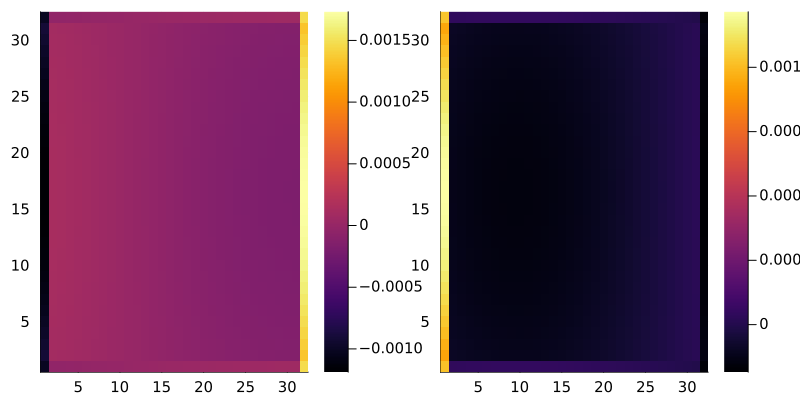

In [8]:
plt = plot(heatmap(check_real[l:r,l:r]),
        heatmap(check_imag[l:r,l:r]),
        labelfontsize=16,tickfontsize=10,size=(800,400),
        legendfontsize=8)

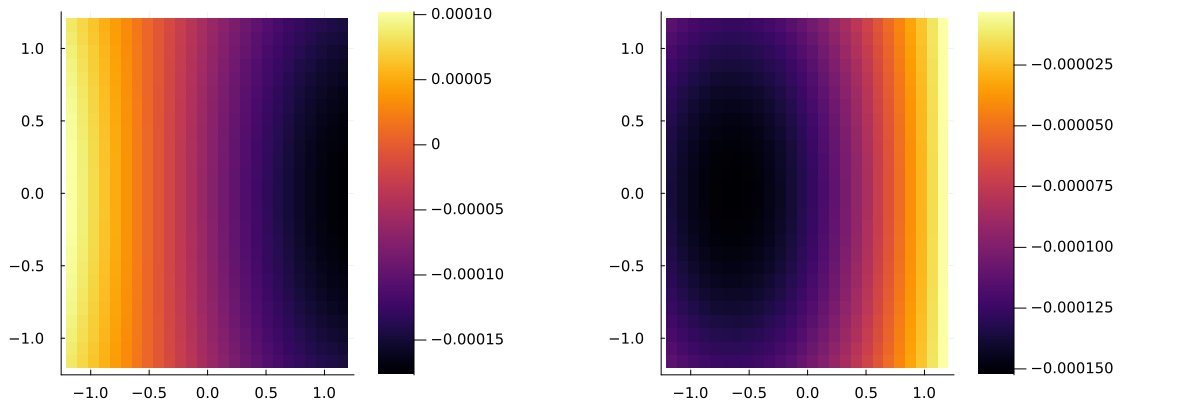

In [9]:
spatial_part = -len/2 + 2*dx:dx:len/2 - 2*dx 

plt = plot(heatmap(spatial_part, spatial_part, check_real[l+3:r-3,l+3:r-3],right_margin=3Plots.cm),
        heatmap(spatial_part, spatial_part, check_imag[l+3:r-3,l+3:r-3],right_margin=3Plots.cm),
        labelfontsize=16,tickfontsize=10,size=(1200,400),
        legendfontsize=8) 

##### Does not get down to the same order of error in this case due to discretised operator $\mathcal{L}$

----
### Extending the domain to show more of the wave field

In [ ]:
include(relpath("newdata/extend_sub.jl","shape_in_wdp"))
# I switched this code to 4 times rather than its current 2 times


sub_ellipse (generic function with 1 method)

In [22]:
Anew = sub_ellipse(0,A[1],A[2],A[5],A[5],5pi)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.9.0.

Number of nonzeros in equality constraint Jacobian...:  3616810
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:   722402
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:   722402
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.0000000e+00 3.90e-01 0.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [-0.07673774450235699 -0.07575518541390877 … -0.016437709539170613 -0.016499821144669385; -0.07588099559123246 -0.07457076339409986 … -0.016248414584994313 -0.01638114288231201; … ; -0.07682410684170118 -0.07653728817973737 … -0.016870450425388005 -0.016774164638058302; -0.0767573937910734 -0.07680479176232895 … -0.01683570987548986 -0.01666619348546173], [0.011527862371319248 0.01651411150913075 … 0.0019299749301230334 0.0008514155641908671; 0.01654687134544461 0.02146568907453588 … 0.0030090357734303616 0.0019343094025991697; … ; 0.0016327887867153695 0.006729865679461766 … -0.0004348699220156349 -0.0015561232496329406; -0.0033666411966884694 0.0017195248943152348 … -0.0015442262382274249 -0.002651312376766874])

In [65]:
side_l = sqrt(pi)pi/4
sq_1 = -side_l:0.01:side_l
z = []
sq_2 = []
sq_3 = []
for i in 1:length(sq_1)
    append!(z,-0.5)
    append!(sq_2, side_l)
    append!(sq_3, -side_l)
end

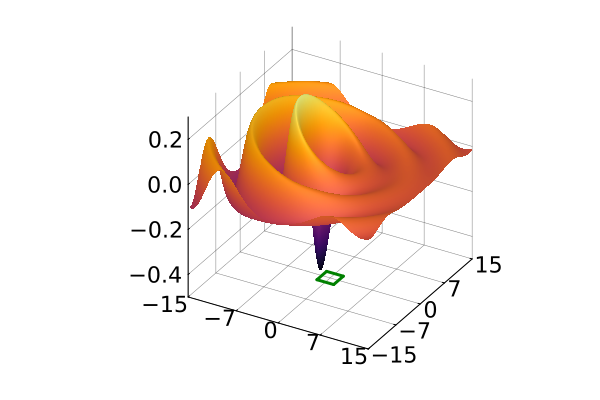

In [105]:
theme(:default)
x = -10len-A[5]:A[5]:10len
plh1 = surface(x,x,Anew[3],colorbar=false,tickfontsize=15,gridalpha=0.5,xlims=[-15,15],
        ylims=[-15,15],xticks=[-15,-7,0,7,15],yticks=[-15,-7,0,7,15],
        zticks=[-0.4,-0.2,0,0.2],margin=0Plots.cm,zlims=[-0.5,0.3])
plot!(plh1,sq_2,sq_1,z,label=false,color="green", 
        linewidth=3)
plot!(plh1,sq_3,sq_1,z,label=false,color="green",  
        linewidth=3)
plot!(plh1,sq_1,sq_2,z,label=false,color="green", 
        linewidth=3)
plot!(plh1,sq_1,sq_3,z,label=false,color="green",  
        linewidth=3)

In [24]:
Bnew = sub_ellipse(0,B[1],B[2],B[5],B[5],5pi)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.9.0.

Number of nonzeros in equality constraint Jacobian...:  3616810
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:   722402
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:   722402
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.0000000e+00 4.02e-01 0.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [-0.07709297274154424 -0.0766646810006393 … -0.016501167279987898 -0.016456791932516167; -0.07679226904513467 -0.07603280590177695 … -0.01641928033248638 -0.016445361695623197; … ; -0.07610514846770325 -0.07637653693099421 … -0.016696236915879056 -0.016490365129007173; -0.07549537470193048 -0.07609588705818766 … -0.016552735538556088 -0.016275597052863133], [0.003042275628766497 0.008078630849673408 … 0.0003010107250231882 -0.000776056285710704; 0.008094087282426454 0.013099458184394227 … 0.0013897649314399737 0.00030953077717636203; … ; -0.006747612013439546 -0.0016776526515125626 … -0.002090593593288663 -0.003194109602881157; -0.011680173134406705 -0.00665730381423474 … -0.0031874214707727864 -0.004269679041222581])

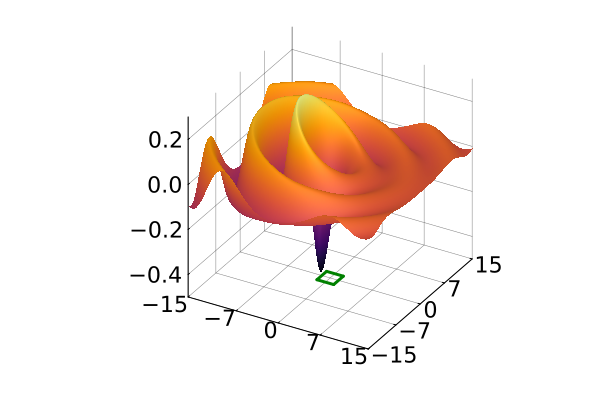

In [107]:
x = -10len-B[5]:B[5]:10len
plh2 = surface(x,x,Bnew[3],colorbar=false,tickfontsize=15,gridalpha=0.5,xlims=[-15,15],
        ylims=[-15,15],xticks=[-15,-7,0,7,15],yticks=[-15,-7,0,7,15],
        zticks=[-0.4,-0.2,0,0.2],margin=0Plots.cm,zlims=[-0.5,0.3])
plot!(plh2,sq_2,sq_1,z,label=false,color="green", 
        linewidth=3)
plot!(plh2,sq_3,sq_1,z,label=false,color="green",  
        linewidth=3)
plot!(plh2,sq_1,sq_2,z,label=false,color="green", 
        linewidth=3)
plot!(plh2,sq_1,sq_3,z,label=false,color="green",  
        linewidth=3)

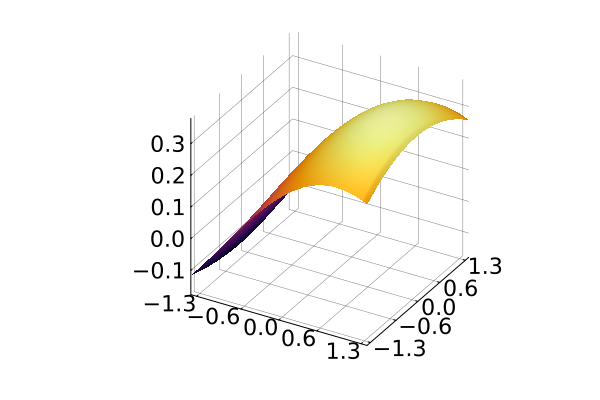

In [110]:
space_array = -5*len/2+A[5]:A[5]:5*len/2+2A[5]
plq1 = Plots.surface(space_array, space_array, A[1],
        xlims=[-len/2,len/2],ylims=[-len/2,len/2],
        colorbar=false,gridalpha=0.5,tickfontsize=15,
        xticks=[-1.3,-0.6,0,0.6,1.3],yticks=[-1.3,-0.6,0,0.6,1.3])

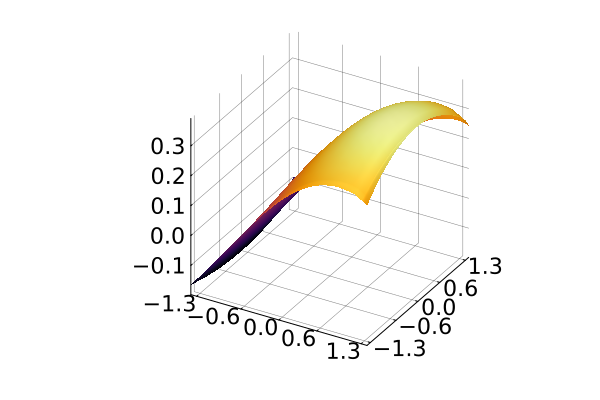

In [112]:
space_array = -5*len/2+B[5]:B[5]:5*len/2+2B[5]
plq2 = Plots.surface(space_array, space_array, B[1],
        xlims=[-len/2,len/2],ylims=[-len/2,len/2],
        colorbar=false,gridalpha=0.5,tickfontsize=15,
        xticks=[-1.3,-0.6,0,0.6,1.3],yticks=[-1.3,-0.6,0,0.6,1.3])
